In [1]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, TimeDistributed, Reshape, LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
print("Done")

Done


In [2]:
# Dataset path and parameters
dataset_path = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
img_size = 150
batch_size = 64
classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
num_classes = len(classes)
# Load and preprocess the dataset
def load_data(dataset_path, classes):
    data = []
    labels = []
    for i, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        print(f"Loading {class_name} images...")
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (img_size, img_size))
                data.append(img)
                labels.append(i)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(data), np.array(labels)

# Load the data
    
print("Loading dataset...")
data, labels = load_data(dataset_path, classes)
print(f"Total data shape: {data.shape}")
print(f"Total labels shape: {labels.shape}")
print(f"Class distribution: {np.bincount(labels)}")



Loading dataset...
Loading Normal images...
Loading Cyst images...
Loading Tumor images...
Loading Stone images...
Total data shape: (12446, 150, 150, 3)
Total labels shape: (12446,)
Class distribution: [5077 3709 2283 1377]


In [3]:
# Normalize pixel values
data = data.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
labels_categorical = to_categorical(labels, num_classes=num_classes)

In [4]:
# Split the dataset into train, validation, and test sets
# First split: separate test set (10%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data, labels_categorical, test_size=0.1, random_state=42, stratify=labels
)

# Second split: separate validation set from training set (20% of remaining = 18% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)

In [5]:
# LSTM-based Model Architecture
def create_lstm_model(input_shape, num_classes):
    # Input Layer
    input_layer = Input(shape=input_shape)
    
    # Reshape for LSTM - splitting the image into patches/sequences
    # Treat each row of the image as a sequence
    # Reshape from (height, width, channels) to (height, width*channels)
    x = Reshape((img_size, img_size * 3))(input_layer)
    
    # LSTM Layers
    x = LSTM(32, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    
    x = LSTM(16, return_sequences=False)(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    
    # Fully Connected Layers
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Output Layer
    output_layer = Dense(num_classes, activation='softmax')(x)
    
    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)
    
    return model

In [6]:
print(f"\nDataset split summary:")
print(f"Training set: {X_train.shape[0]} images ({X_train.shape[0]/len(data)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} images ({X_val.shape[0]/len(data)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} images ({X_test.shape[0]/len(data)*100:.1f}%)")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")

# Create the model
model = create_lstm_model((img_size, img_size, 3), num_classes)

# Compile the model
# Compile the model
from tensorflow.keras.optimizers import SGD

model.compile(optimizer=SGD(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()




Dataset split summary:
Training set: 8960 images (72.0%)
Validation set: 2241 images (18.0%)
Test set: 1245 images (10.0%)
Total: 12446 images


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 450)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150, 32)        │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,292 (258.95 KB)

 Trainable params: 66,196 (258.58 KB)

 Non-trainable params: 96 (384.00 B)

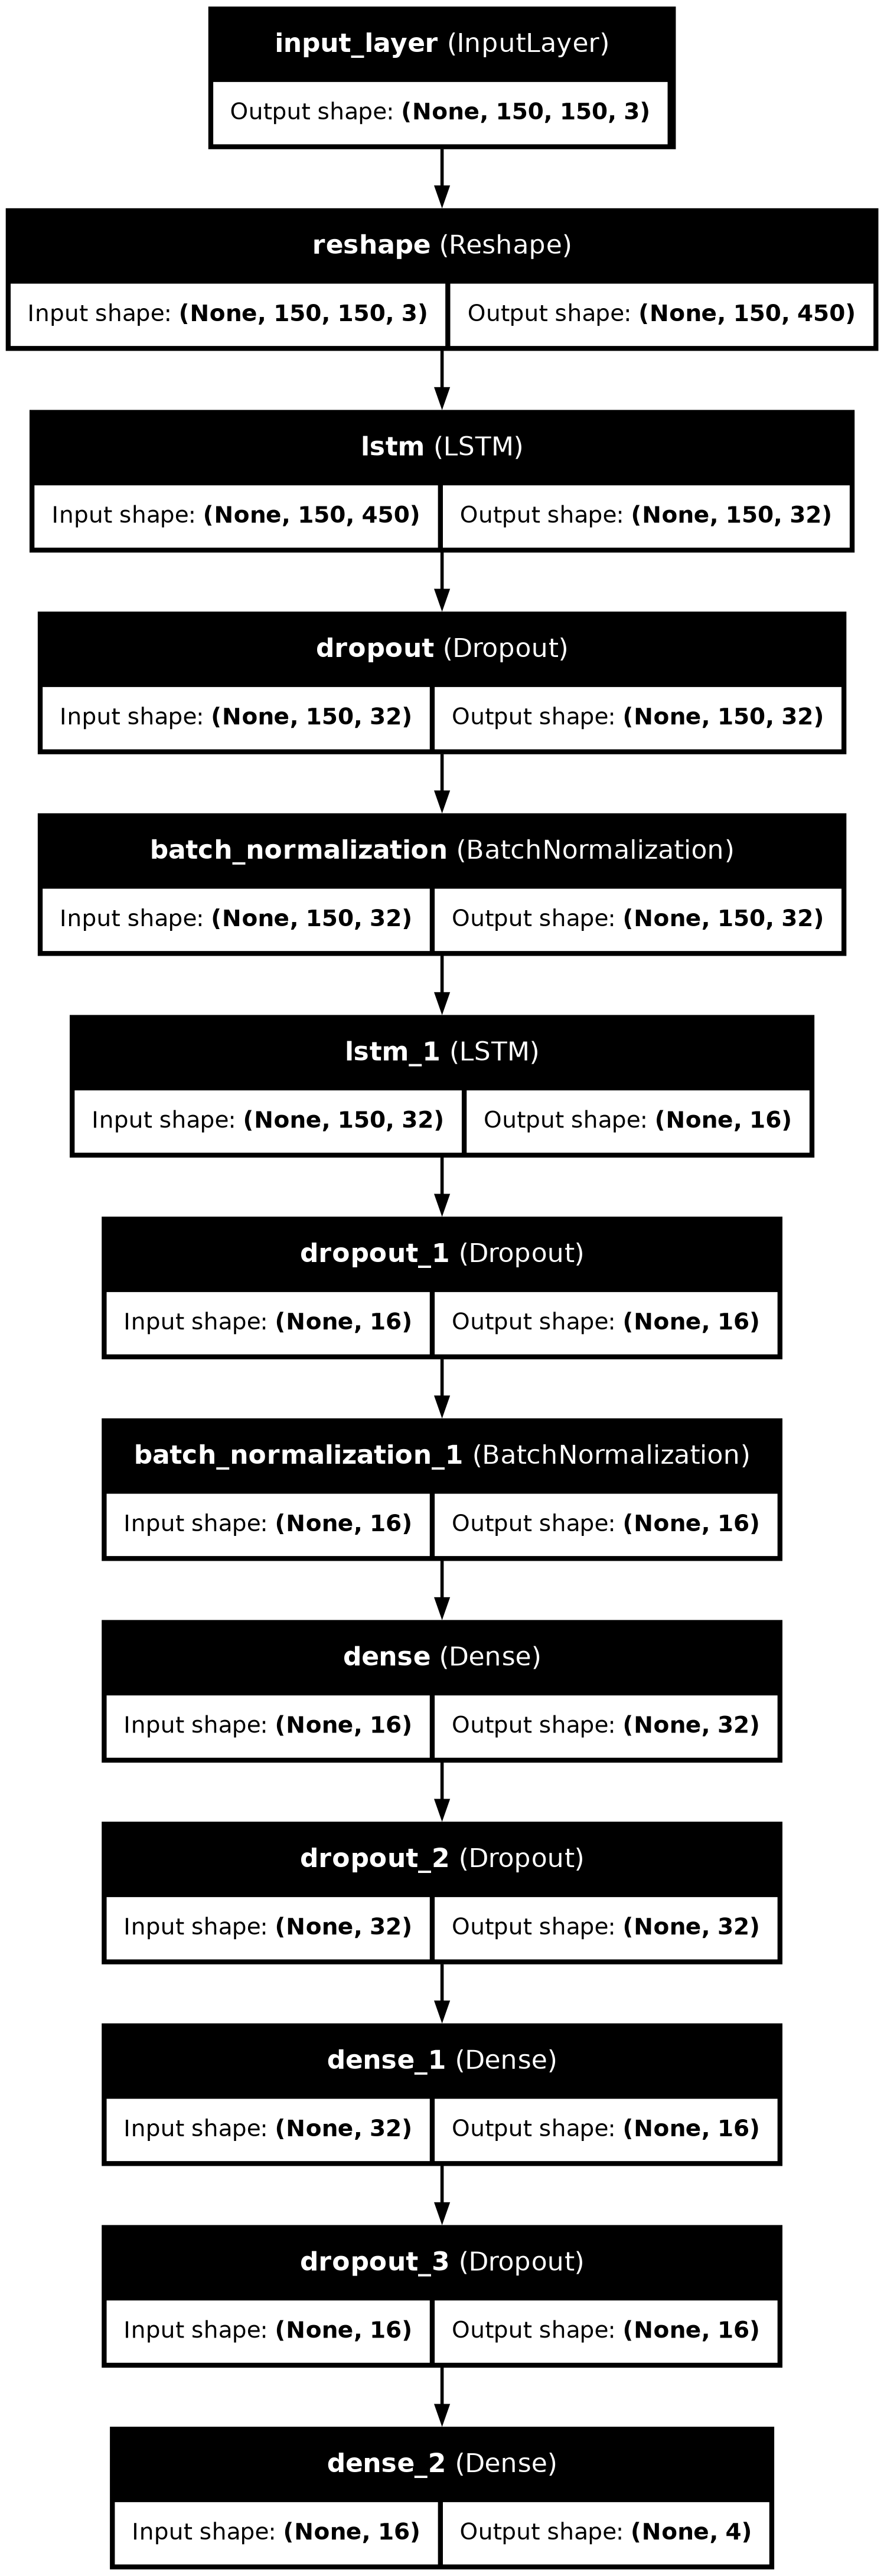

In [7]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True, show_layer_names=True, rankdir='TB', expand_nested=True)

In [8]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=80,
    verbose=1
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.3114 - loss: 1.4731 - val_accuracy: 0.4150 - val_loss: 1.3117
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3933 - loss: 1.3293 - val_accuracy: 0.4743 - val_loss: 1.2516
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4184 - loss: 1.2794 - val_accuracy: 0.4917 - val_loss: 1.2051
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4395 - loss: 1.2461 - val_accuracy: 0.5538 - val_loss: 1.1413
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4737 - loss: 1.2018 - val_accuracy: 0.5828 - val_loss: 1.0633
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5161 - loss: 1.1422 - val_accuracy: 0.6328 - val_loss: 0.9624
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5658 - loss: 1.0670 - val_accuracy: 0.6720 - val_loss: 0.8335
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6001 - loss: 0.9895 - val_accu

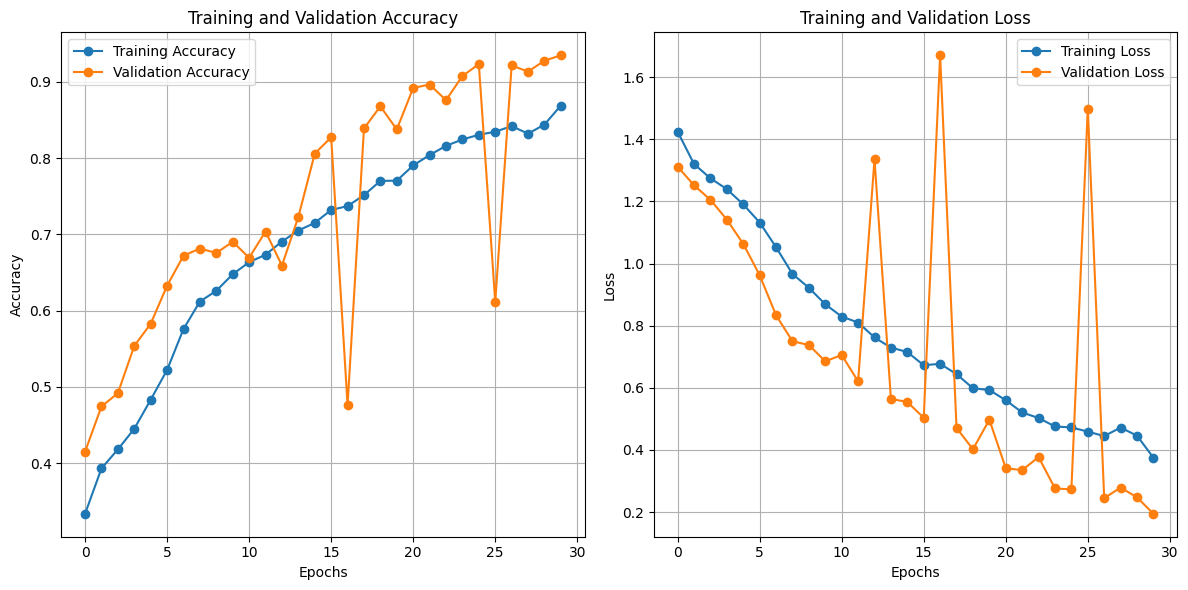

In [9]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Display the plots
plt.tight_layout()
plt.show()


In [10]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Save the model
#model.save('cnn_bilstm_kidney_classification.h5')

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9302 - loss: 0.2075
Test Accuracy: 93.09%


Test Accuracy: 93.09%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       508
        Cyst       0.94      0.93      0.93       371
       Tumor       0.93      0.93      0.93       228
       Stone       0.81      0.74      0.77       138

    accuracy                           0.93      1245
   macro avg       0.91      0.90      0.90      1245
weighted avg       0.93      0.93      0.93      1245

Precision: 0.9295%
Recall: 0.9309%
F1 Score: 0.9299%

Confusion Matrix:
[[500   0   3   5]
 [  1 344   9  17]
 [  8   5 213   2]
 [ 14  18   4 102]]


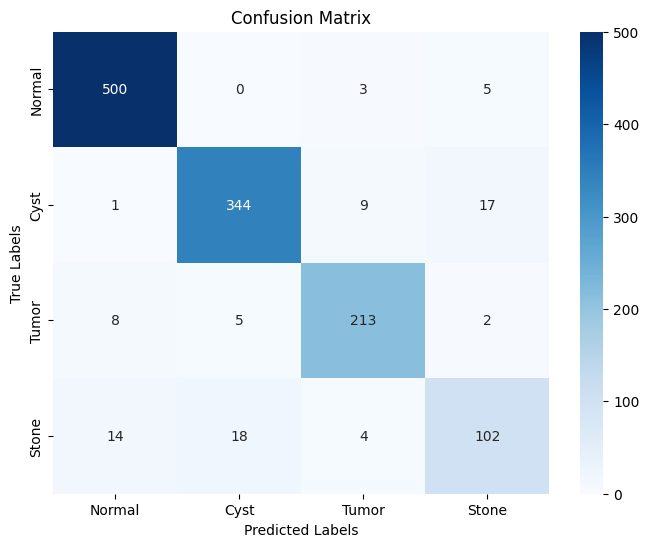

In [11]:
# Evaluate the model on the test data
from sklearn.metrics import precision_score, recall_score, f1_score
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Predict on the test set
y_pred = model.predict(X_test, verbose=0)

# Convert predictions and true labels to categorical format
y_pred_classes = np.argmax(y_pred, axis=1)  # Predicted classes
y_true_classes = np.argmax(y_test, axis=1)  # True classes

# Calculate precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))


# Calculate precision, recall, F1 score, and confusion matrix
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')


# Print the results
print(f"Precision: {precision:.4f}%")
print(f"Recall: {recall:.4f}%")
print(f"F1 Score: {f1:.4f}%")


conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


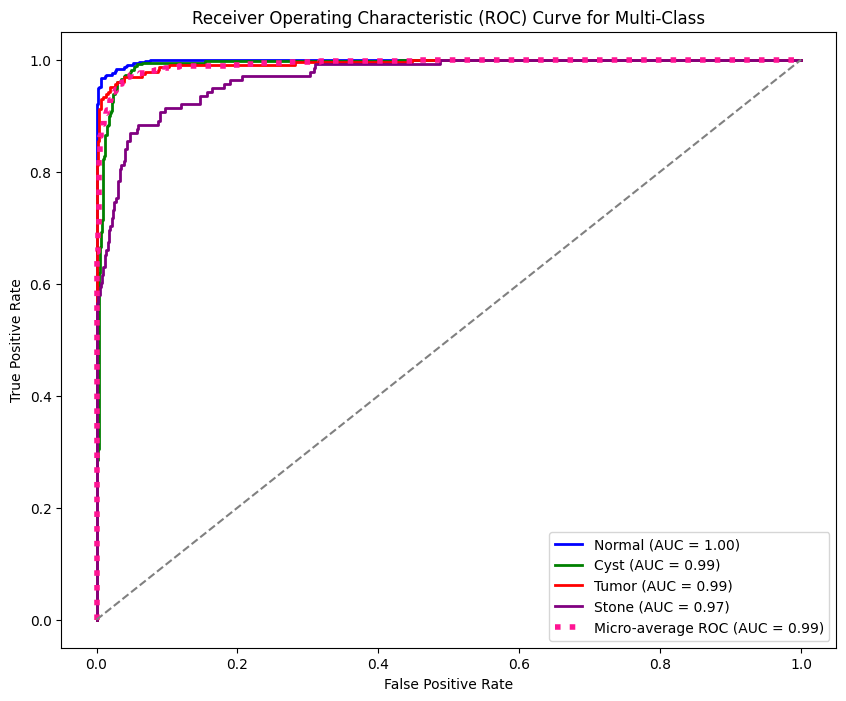

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Define class names
classes = ['Normal', 'Cyst', 'Tumor', 'Stone']


# Binarize the labels for multi-class (One-vs-Rest)
n_classes = y_test.shape[1]  # Assuming y_test is one-hot encoded
y_test_binarized = label_binarize(np.argmax(y_test, axis=1), classes=range(n_classes))
y_pred_probs = model.predict(X_test) 


# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple']  # Add more colors if needed
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})')

# Plot the diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Add plot labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-Class')
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


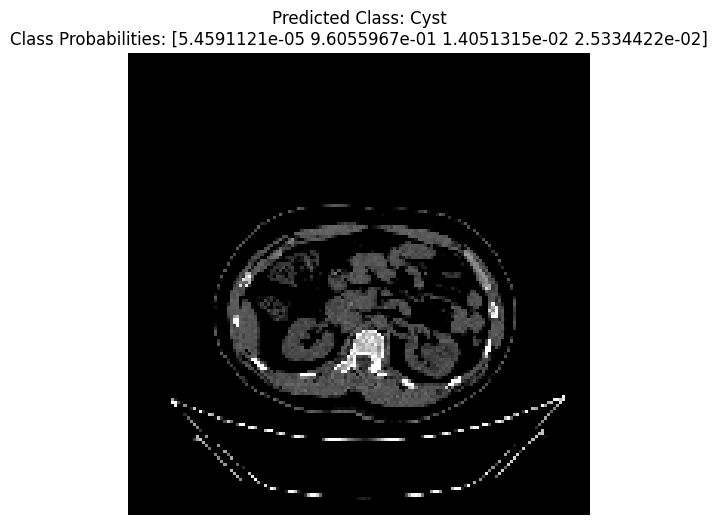

Predicted class: Cyst
Class probabilities: [5.4591121e-05 9.6055967e-01 1.4051315e-02 2.5334422e-02]


In [13]:
# Load and preprocess the image
image_path = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1009).jpg'

# Load the image with target size same as the input size of the model
img = load_img(image_path, target_size=(img_size, img_size))
img_array = img_to_array(img)  # Convert to numpy array
img_array = img_array / 255.0  # Normalize the image (same as during training)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict the class of the image
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])  # Get the index of the highest probability

# Map the predicted index to the class name
predicted_class_name = classes[predicted_class]

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # Hide the axis
plt.title(f"Predicted Class: {predicted_class_name}\nClass Probabilities: {predictions[0]}")
plt.show()

# Print the result
print(f"Predicted class: {predicted_class_name}")
print(f"Class probabilities: {predictions[0]}")